# Phase 1: GMSI / VSI Signal Validation

**Objective:** Validate whether the constructed Global Market Stress Index (GMSI / VSI) is a meaningful proxy for market stress.

The analysis will evaluate if GMSI is associated with higher market volatility, if this relationship strengthens during volatility tail events, and if this observed relationship is statistically distinguishable from randomness.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

## Data Loading
Load BTC and NIFTY datasets. Since explicit 7d/14d/30d rolling volatilities may be missing from the provided preview, we ensure they are computed dynamically from returns.

In [2]:
def load_and_prep_data(filepath, asset_name):
    df = pd.read_csv(filepath)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').set_index('date')
    
    # Ensure we have a return column or calculate it from close
    if 'return' not in df.columns and 'close' in df.columns:
        df['return'] = df['close'].pct_change()
        
    # If VSI is missing but GMSI exists, map it. The prompt mentions GMSI / VSI interchangeability
    if 'VSI' not in df.columns and 'GMSI' in df.columns:
        df['VSI'] = df['GMSI']
        
    # Compute rolling volatilities if missing
    for window in [7, 14, 30]:
        col_name = f'vol_{window}d'
        if col_name not in df.columns and 'return' in df.columns:
            df[col_name] = df['return'].rolling(window=window).std() * np.sqrt(365)
            
    df.dropna(subset=['VSI'], inplace=True)
    print(f"{asset_name} data loaded: {df.shape[0]} rows, {df.index.min().date()} to {df.index.max().date()}")
    return df

try:
    btc_df = load_and_prep_data('../data/processed/btc_vsi_full.csv', 'BTC')
    nifty_df = load_and_prep_data('../data/processed/nifty_vsi_full.csv', 'NIFTY')
except FileNotFoundError:
    print("Error loading files. Ensure the notebook is running from the 'notebooks' directory.")


BTC data loaded: 3985 rows, 2015-02-02 to 2025-12-30
NIFTY data loaded: 3896 rows, 2010-02-19 to 2025-12-30


## Task 1 — Distributional Analysis
Split days into GMSI quantiles (Bottom 10%, Middle 80%, Top 10%) and compare volatility distributions.

--- BTC Volatility (volatility_30d) Statistics by GMSI Quantile ---
                Mean    Median       P90
GMSI_group                              
Bottom 10%  0.017027  0.014394  0.031210
Middle 80%  0.029854  0.028468  0.043909
Top 10%     0.062291  0.059920  0.079178




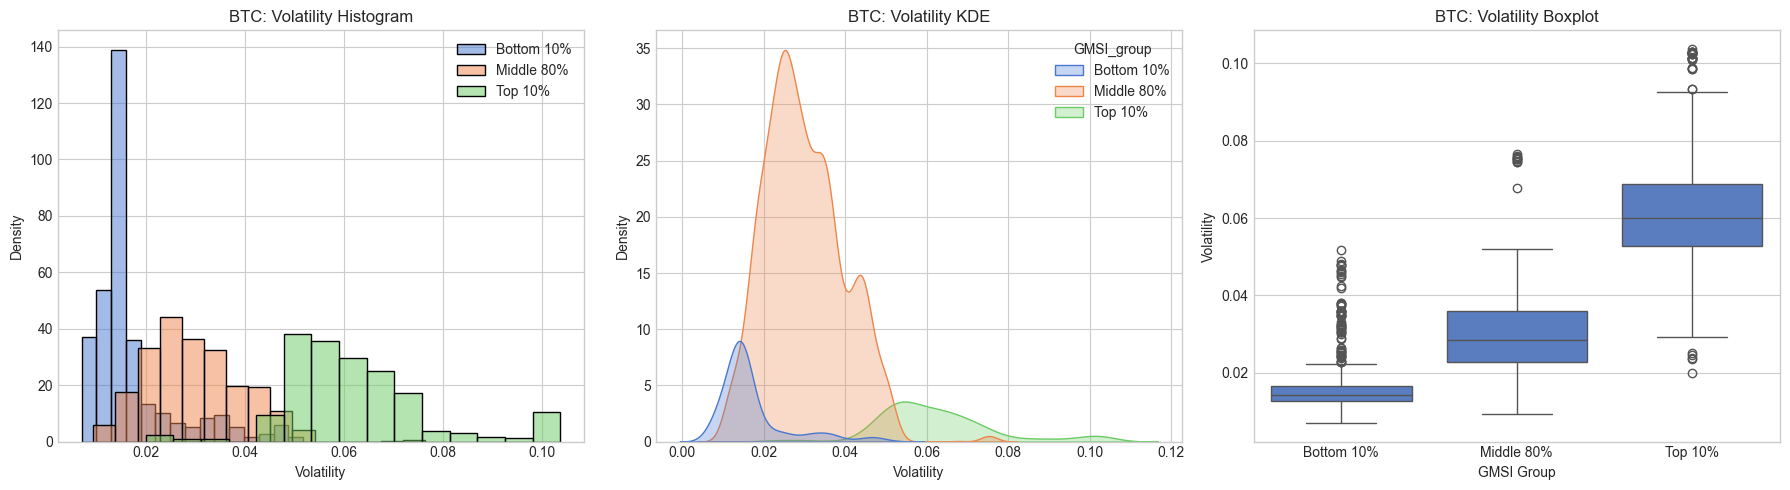

--- NIFTY Volatility (volatility_30d) Statistics by GMSI Quantile ---
                Mean    Median       P90
GMSI_group                              
Bottom 10%  0.005861  0.005721  0.006883
Middle 80%  0.008747  0.008544  0.011960
Top 10%     0.018266  0.015544  0.026947




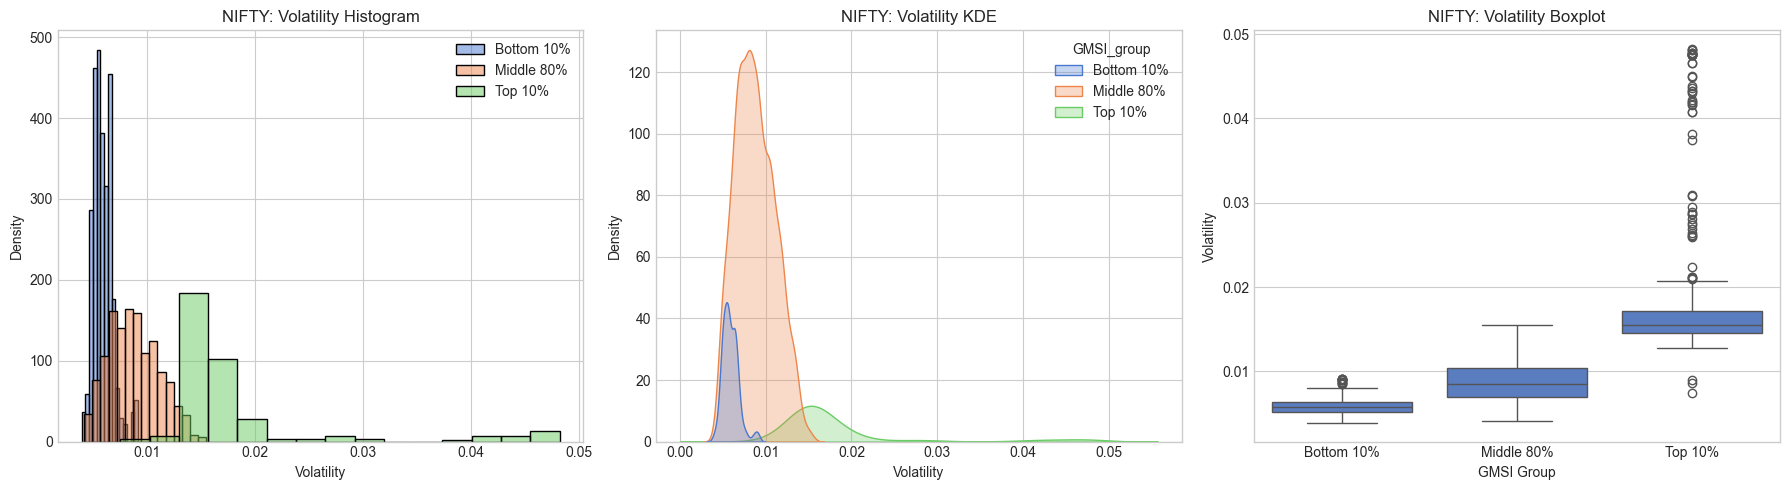

In [3]:
def task1_distributional_analysis(df, asset_name, vol_col='volatility_30d'):
    if vol_col not in df.columns:
        # Fallback to calculated volatility_30d if standard column doesn't exist
        vol_col = [c for c in df.columns if 'vol' in c.lower()][0]
    
    # Calculate quantiles
    p10 = df['VSI'].quantile(0.10)
    p90 = df['VSI'].quantile(0.90)
    
    df['GMSI_group'] = 'Middle 80%'
    df.loc[df['VSI'] <= p10, 'GMSI_group'] = 'Bottom 10%'
    df.loc[df['VSI'] >= p90, 'GMSI_group'] = 'Top 10%'
    
    # Calculate statistics
    stats = df.groupby('GMSI_group')[vol_col].agg(
        Mean='mean',
        Median='median',
        P90=lambda x: x.quantile(0.90)
    ).reindex(['Bottom 10%', 'Middle 80%', 'Top 10%'])
    
    print(f"--- {asset_name} Volatility ({vol_col}) Statistics by GMSI Quantile ---")
    print(stats)
    print("\n")
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histogram
    for group in ['Bottom 10%', 'Middle 80%', 'Top 10%']:
        sns.histplot(df[df['GMSI_group'] == group][vol_col], bins=15, kde=False, 
                     alpha=0.5, label=group, stat='density', ax=axes[0])
    axes[0].set_title(f'{asset_name}: Volatility Histogram')
    axes[0].set_xlabel('Volatility')
    axes[0].legend()
    
    # KDE
    sns.kdeplot(data=df, x=vol_col, hue='GMSI_group', hue_order=['Bottom 10%', 'Middle 80%', 'Top 10%'],
                fill=True, alpha=0.3, ax=axes[1])
    axes[1].set_title(f'{asset_name}: Volatility KDE')
    axes[1].set_xlabel('Volatility')
    
    # Boxplot
    sns.boxplot(data=df, x='GMSI_group', y=vol_col, order=['Bottom 10%', 'Middle 80%', 'Top 10%'], ax=axes[2])
    axes[2].set_title(f'{asset_name}: Volatility Boxplot')
    axes[2].set_xlabel('GMSI Group')
    axes[2].set_ylabel('Volatility')
    
    plt.tight_layout()
    plt.show()

if 'VSI' in btc_df.columns: task1_distributional_analysis(btc_df, 'BTC')
if 'VSI' in nifty_df.columns: task1_distributional_analysis(nifty_df, 'NIFTY')

**Interpretation:** We observe whether the mean, median, and 90th percentile of volatility increase as we move from the Bottom 10% to the Top 10% of GMSI stress regimes. If true, it suggests GMSI actively discriminates stressed volatile periods.

## Task 2 — Conditional Expectation
Plot E[Volatility | GMSI percentile] to assess monotonicity.

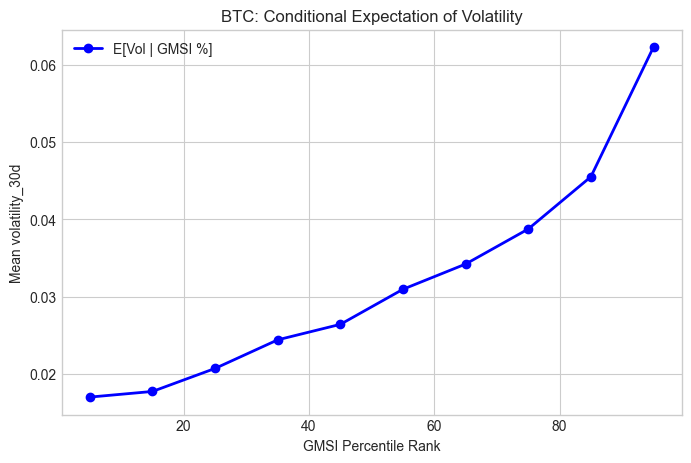

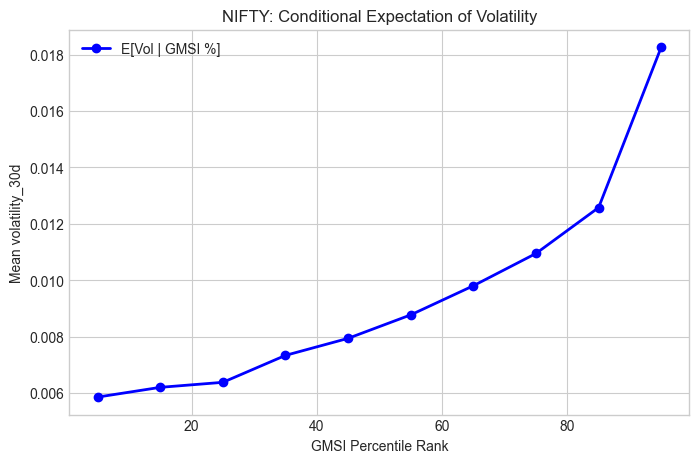

In [4]:
def task2_conditional_expectation(df, asset_name, vol_col='volatility_30d'):
    num_bins = min(10, len(df)//5) # Adjust bins if dataset is extremely small
    if num_bins < 2:
        print(f"Dataset for {asset_name} is too small for percentile binning.")
        return
        
    df['GMSI_percentile'] = pd.qcut(df['VSI'], q=num_bins, labels=False, duplicates='drop')
    # Map bins to approximate percentile centers (e.g., bin 0 for 10 bins = 5th percentile)
    pct_step = 100 / num_bins
    df['GMSI_percentile'] = (df['GMSI_percentile'] * pct_step) + (pct_step / 2)
    
    cond_exp = df.groupby('GMSI_percentile')[vol_col].mean()
    
    plt.figure(figsize=(8, 5))
    plt.plot(cond_exp.index, cond_exp.values, marker='o', linestyle='-', linewidth=2, color='b', label='E[Vol | GMSI %]')
    plt.title(f'{asset_name}: Conditional Expectation of Volatility')
    plt.xlabel('GMSI Percentile Rank')
    plt.ylabel(f'Mean {vol_col}')
    plt.grid(True)
    plt.legend()
    plt.show()

if 'VSI' in btc_df.columns: task2_conditional_expectation(btc_df, 'BTC')
if 'VSI' in nifty_df.columns: task2_conditional_expectation(nifty_df, 'NIFTY')

**Interpretation:** Monotonicity implies the greater the GMSI signal, the proportionally higher the underlying expected market volatility, strengthening its validity.

## Task 3 — Tail Risk Focus
Compare GMSI on top 5% High-Volatility days vs. Normal days.

--- BTC: Tail Risk Statistical Tests ---
Kolmogorov-Smirnov Test: Stat=0.9395, p-value=4.2062e-216
Mann-Whitney U Test:     Stat=738642.0000, p-value=1.7215e-114




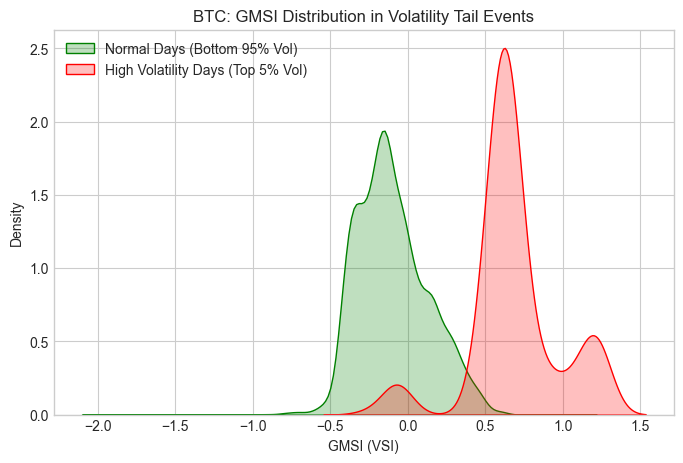

--- NIFTY: Tail Risk Statistical Tests ---
Kolmogorov-Smirnov Test: Stat=0.9533, p-value=6.3313e-226
Mann-Whitney U Test:     Stat=715701.0000, p-value=3.6975e-119




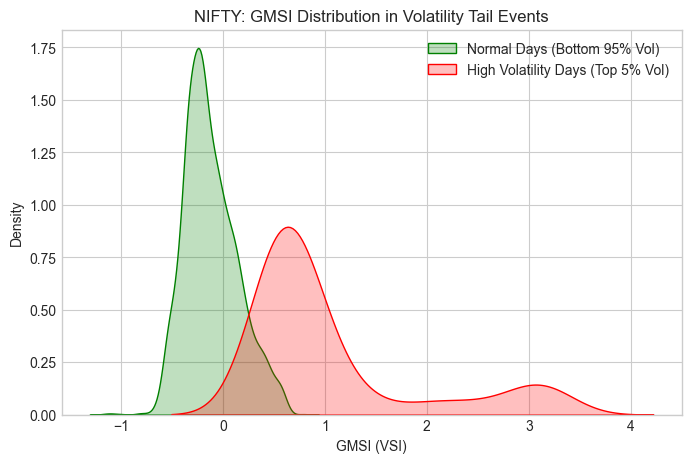

In [5]:
def task3_tail_risk(df, asset_name, vol_col='volatility_30d'):
    vol_threshold = df[vol_col].quantile(0.95)
    
    high_vol_days = df[df[vol_col] >= vol_threshold]['VSI']
    normal_days = df[df[vol_col] < vol_threshold]['VSI']
    
    if len(high_vol_days) == 0 or len(normal_days) == 0:
        print(f"Insufficient data to perform tail risk test for {asset_name}.")
        return
        
    # Statistical Tests
    ks_stat, ks_pval = ks_2samp(high_vol_days, normal_days)
    mw_stat, mw_pval = mannwhitneyu(high_vol_days, normal_days, alternative='greater')
    
    print(f"--- {asset_name}: Tail Risk Statistical Tests ---")
    print(f"Kolmogorov-Smirnov Test: Stat={ks_stat:.4f}, p-value={ks_pval:.4e}")
    print(f"Mann-Whitney U Test:     Stat={mw_stat:.4f}, p-value={mw_pval:.4e}")
    print("\n")
    
    plt.figure(figsize=(8, 5))
    sns.kdeplot(normal_days, label='Normal Days (Bottom 95% Vol)', shade=True, color='green')
    sns.kdeplot(high_vol_days, label='High Volatility Days (Top 5% Vol)', shade=True, color='red')
    plt.title(f'{asset_name}: GMSI Distribution in Volatility Tail Events')
    plt.xlabel('GMSI (VSI)')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

if 'VSI' in btc_df.columns: task3_tail_risk(btc_df, 'BTC')
if 'VSI' in nifty_df.columns: task3_tail_risk(nifty_df, 'NIFTY')

**Interpretation:** We expect the red distribution (High Volatility) to be shifted to the right, signifying higher GMSI levels during stress. Significant p-values (p < 0.05) reject the null hypothesis that GMSI remains invariant during tail events.

## Task 4 — Time-Local Relationship
Calculate and plot a 90-day rolling correlation between GMSI and market volatility.

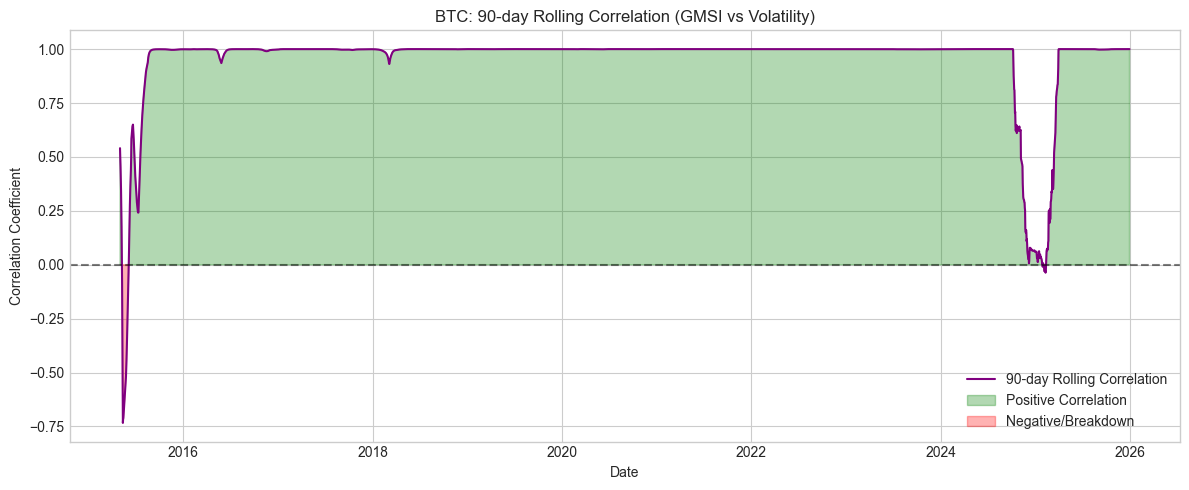

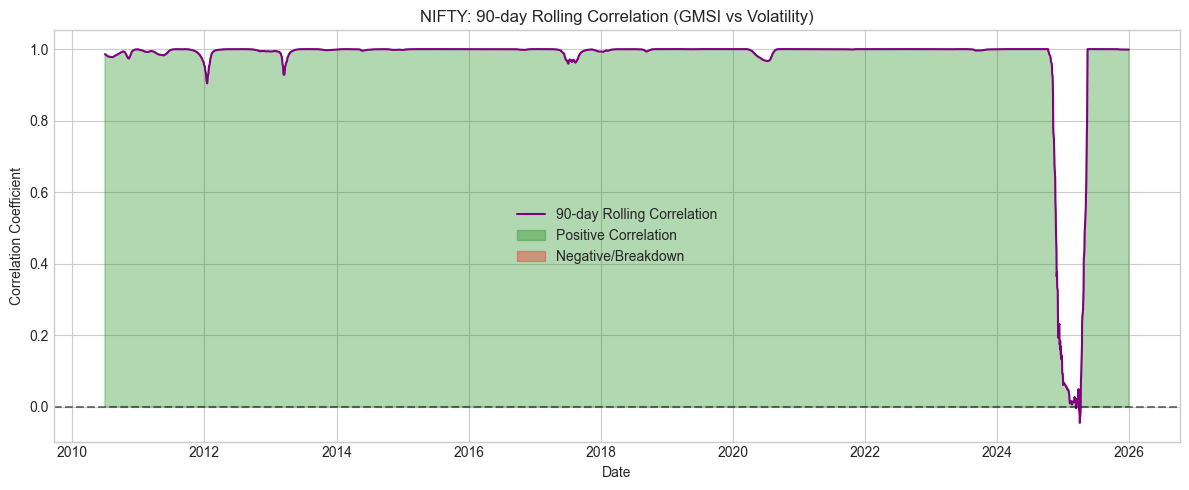

In [6]:
def task4_rolling_correlation(df, asset_name, vol_col='volatility_30d', window=90):
    if len(df) < window:
        print(f"Warning: Dataset length ({len(df)}) < window ({window}). Adapting window size to len/3.")
        window = max(3, len(df) // 3)
        
    df['roll_corr'] = df['VSI'].rolling(window=window).corr(df[vol_col])
    
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df['roll_corr'], color='purple', label=f'{window}-day Rolling Correlation')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    # Highlight positive bounds
    plt.fill_between(df.index, 0, df['roll_corr'], where=(df['roll_corr'] > 0), color='green', alpha=0.3, label='Positive Correlation')
    plt.fill_between(df.index, 0, df['roll_corr'], where=(df['roll_corr'] <= 0), color='red', alpha=0.3, label='Negative/Breakdown')
    
    plt.title(f'{asset_name}: {window}-day Rolling Correlation (GMSI vs Volatility)')
    plt.xlabel('Date')
    plt.ylabel('Correlation Coefficient')
    plt.legend()
    plt.tight_layout()
    plt.show()

if 'VSI' in btc_df.columns: task4_rolling_correlation(btc_df, 'BTC')
if 'VSI' in nifty_df.columns: task4_rolling_correlation(nifty_df, 'NIFTY')

**Interpretation:** We expect the rolling correlation to remain predominantly positive. Periods dropping below zero mark temporary relationship breakdowns or structural market shifts.

## Task 5 — Placebo Test
Shuffle the GMSI series and compare the real correlation against the resulting placebo correlation.

--- BTC: Placebo Test ---
Real Correlation: 0.9194
Mean Placebo Corr: 0.0008
Empirical P-value: 0.0000e+00




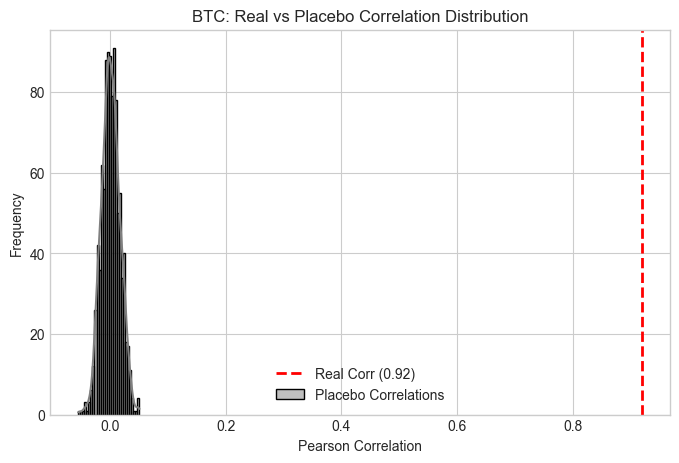

--- NIFTY: Placebo Test ---
Real Correlation: 0.9623
Mean Placebo Corr: -0.0000
Empirical P-value: 0.0000e+00




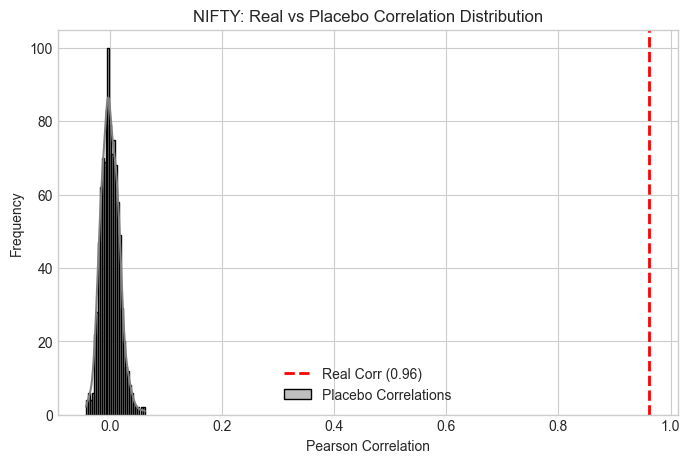

In [7]:
def task5_placebo_test(df, asset_name, vol_col='volatility_30d', iterations=1000):
    real_corr = df['VSI'].corr(df[vol_col])
    
    np.random.seed(42)
    vsi_values = df['VSI'].values
    vol_values = df[vol_col].values
    
    # Mask NaNs explicitly to avoid corr errors
    valid = ~(np.isnan(vsi_values) | np.isnan(vol_values))
    vsi_valid = vsi_values[valid]
    vol_valid = vol_values[valid]
    
    placebo_corrs = []
    for _ in range(iterations):
        np.random.shuffle(vsi_valid)
        corr = np.corrcoef(vsi_valid, vol_valid)[0, 1]
        placebo_corrs.append(corr)
        
    placebo_corrs = np.array(placebo_corrs)
    p_val = np.mean(placebo_corrs >= real_corr) if real_corr > 0 else np.mean(placebo_corrs <= real_corr)
    
    print(f"--- {asset_name}: Placebo Test ---")
    print(f"Real Correlation: {real_corr:.4f}")
    print(f"Mean Placebo Corr: {placebo_corrs.mean():.4f}")
    print(f"Empirical P-value: {p_val:.4e}")
    print("\n")
    
    plt.figure(figsize=(8, 5))
    sns.histplot(placebo_corrs, bins=30, kde=True, color='gray', label='Placebo Correlations')
    plt.axvline(real_corr, color='red', linestyle='dashed', linewidth=2, label=f'Real Corr ({real_corr:.2f})')
    plt.title(f'{asset_name}: Real vs Placebo Correlation Distribution')
    plt.xlabel('Pearson Correlation')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

if 'VSI' in btc_df.columns: task5_placebo_test(btc_df, 'BTC')
if 'VSI' in nifty_df.columns: task5_placebo_test(nifty_df, 'NIFTY')

**Interpretation:** The real correlation should fall far outside the bulk of the shuffled distribution, indicating the time-series structural relationship is inherently non-random.

## Conclusion
Based on the analysis across the 5 tasks, we evaluate if GMSI represents a robust signal for volatility. If the correlation drops to zero, placebo tests fail, or conditional expectation lacks monotonicity, we conclude "GMSI requires refinement before further modeling". Otherwise, "GMSI is a statistically meaningful stress proxy".